In [ ]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# Notebook 3: Custom CNN Model from Scratch
# ============================================================
# This notebook covers:
# - Mount Google Drive
# - Load dataset using ImageDataGenerator
# - Build Custom CNN architecture from scratch
# - Train with EarlyStopping & ModelCheckpoint
# - Plot training history
# - Save model as .h5
# ============================================================

In [5]:
from google.colab import drive
drive.mount('/content/drive')
print(" Google Drive mounted successfully")

Mounted at /content/drive
 Google Drive mounted successfully


In [8]:
#  Install & Import Libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print(f" TensorFlow version : {tf.__version__}")
print(f" GPU available      : {tf.config.list_physical_devices('GPU')}")

 TensorFlow version : 2.20.0
 GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [18]:
# ── Paths ──────────────────────────────────────────────────
BASE_DIR  = "/content/drive/MyDrive/BrainTumor"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# ── Parameters ─────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 50
NUM_CLASSES = 4
CLASSES     = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

# ── Model save path ────────────────────────────────────────
MODEL_SAVE_PATH = "/content/drive/MyDrive/BrainTumor/models/custom_cnn.h5"
os.makedirs("/content/drive/MyDrive/BrainTumor/models", exist_ok=True)

print(f" Train dir  : {TRAIN_DIR}")
print(f" Valid dir  : {VALID_DIR}")
print(f" Test  dir  : {TEST_DIR}")
print(f" Model save : {MODEL_SAVE_PATH}")

 Train dir  : /content/drive/MyDrive/BrainTumor/train
 Valid dir  : /content/drive/MyDrive/BrainTumor/valid
 Test  dir  : /content/drive/MyDrive/BrainTumor/test
 Model save : /content/drive/MyDrive/BrainTumor/models/custom_cnn.h5


In [10]:
#  Data Generators

# Training — with augmentation
train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 20,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    horizontal_flip    = True,
    zoom_range         = 0.15,
    brightness_range   = [0.8, 1.2],
    fill_mode          = 'nearest'
)

# Validation & Test — normalize only
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    classes     = CLASSES,
    shuffle     = True,
    seed        = 42
)

valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    classes     = CLASSES,
    shuffle     = False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    classes     = CLASSES,
    shuffle     = False
)

print(f" Train samples : {train_generator.n}")
print(f" Valid samples : {valid_generator.n}")
print(f" Test  samples : {test_generator.n}")
print(f" Class indices : {train_generator.class_indices}")

Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Found 246 images belonging to 4 classes.
 Train samples : 1695
 Valid samples : 502
 Test  samples : 246
 Class indices : {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


In [11]:
# Build Custom CNN

def build_custom_cnn(input_shape=(224, 224, 3), num_classes=4):
    model = Sequential([

        # ── Block 1 ────────────────────────────────────────
        Conv2D(32, (3,3), activation='relu', padding='same',
               input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),

        # ── Block 2 ────────────────────────────────────────
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),

        # ── Block 3 ────────────────────────────────────────
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),

        # ── Block 4 ────────────────────────────────────────
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),

        # ── Classifier head ────────────────────────────────
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

model = build_custom_cnn()
model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

model.summary()
print(f"\n Total parameters : {model.count_params():,}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 685,220 (2.61 MB)

 Trainable params: 683,300 (2.61 MB)

 Non-trainable params: 1,920 (7.50 KB)


 Total parameters : 685,220


In [12]:
# Callbacks

callbacks = [
    # Stop training if val_loss doesn't improve for 10 epochs
    EarlyStopping(
        monitor   = 'val_loss',
        patience  = 10,
        verbose   = 1,
        restore_best_weights = True
    ),

    # Save best model automatically
    ModelCheckpoint(
        filepath       = MODEL_SAVE_PATH,
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    ),

    # Reduce learning rate when stuck
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 5,
        verbose  = 1,
        min_lr   = 1e-7
    )
]

print(" Callbacks configured:")
print("   → EarlyStopping    : patience=10, monitor=val_loss")
print("   → ModelCheckpoint  : saves best val_accuracy model")
print("   → ReduceLROnPlateau: factor=0.5, patience=5")


 Callbacks configured:
   → EarlyStopping    : patience=10, monitor=val_loss
   → ModelCheckpoint  : saves best val_accuracy model
   → ReduceLROnPlateau: factor=0.5, patience=5


In [13]:
# Train Model

print(" Starting Custom CNN Training...")
print("=" * 50)

history = model.fit(
    train_generator,
    epochs          = EPOCHS,
    validation_data = valid_generator,
    callbacks       = callbacks,
    verbose         = 1
)

print("\n Training complete!")
print(f"   Best val_accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"   Best val_loss     : {min(history.history['val_loss']):.4f}")
print(f"   Total epochs ran  : {len(history.history['loss'])}")

 Starting Custom CNN Training...
Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5019 - loss: 1.2590
Epoch 1: val_accuracy improved from None to 0.23506, saving model to /content/drive/MyDrive/ BrainTumor/models/custom_cnn.h5



Epoch 1: finished saving model to /content/drive/MyDrive/ BrainTumor/models/custom_cnn.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 668s 12s/step - accuracy: 0.5752 - loss: 1.1155 - val_accuracy: 0.2351 - val_loss: 2.5759 - learning_rate: 0.0010
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.6476 - loss: 0.9378
Epoch 2: val_accuracy did not improve from 0.23506
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 677ms/step - accuracy: 0.6584 - loss: 0.9181 - val_accuracy: 0.2351 - val_loss: 2.8787 - learning_rate: 0.0010
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.6812 - loss: 0.8488
Epoch 3: val_accuracy improved from 0.23506 to 0.26494, saving model to /content/drive/MyDrive/ BrainTumor/models/custom_cnn.h5



Epoch 3: finished saving model to /content/drive/MyDrive/ BrainTumor/models/custom_cnn.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 38s 721ms/step - accuracy: 0.6761 - loss: 0.8532 - val_accuracy: 0.2649 - val_loss: 4.4025 - learning_rate: 0.0010
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.6929 - loss: 0.8379
Epoch 4: val_accuracy did not improve from 0.26494
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 656ms/step - accuracy: 0.6850 - loss: 0.8658 - val_accuracy: 0.2351 - val_loss: 3.8158 - learning_rate: 0.0010
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.7251 - loss: 0.6976
Epoch 5: val_accuracy did not improve from 0.26494
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 678ms/step - accuracy: 0.7127 - loss: 0.7142 - val_accuracy: 0.1972 - val_loss: 4.0476 - learning_rate: 0.0010
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.7416 - loss: 0.6888
Epoch 6: val_accuracy did not improve from 0.26494

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487


Epoch 10: finished saving model to /content/drive/MyDrive/ BrainTumor/models/custom_cnn.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 680ms/step - accuracy: 0.7829 - loss: 0.5706 - val_accuracy: 0.2869 - val_loss: 1.8900 - learning_rate: 5.0000e-04
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.7954 - loss: 0.5616
Epoch 11: val_accuracy improved from 0.28685 to 0.62550, saving model to /content/drive/MyDrive/ BrainTumor/models/custom_cnn.h5



Epoch 11: finished saving model to /content/drive/MyDrive/ BrainTumor/models/custom_cnn.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 698ms/step - accuracy: 0.7988 - loss: 0.5493 - val_accuracy: 0.6255 - val_loss: 0.8134 - learning_rate: 5.0000e-04
Epoch 12/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.8174 - loss: 0.5127
Epoch 12: val_accuracy did not improve from 0.62550
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 658ms/step - accuracy: 0.7947 - loss: 0.5514 - val_accuracy: 0.3386 - val_loss: 1.9818 - learning_rate: 5.0000e-04
Epoch 13/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.8099 - loss: 0.5103
Epoch 13: val_accuracy did not improve from 0.62550
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 672ms/step - accuracy: 0.8000 - loss: 0.5395 - val_accuracy: 0.3785 - val_loss: 6.5853 - learning_rate: 5.0000e-04
Epoch 14/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.8071 - loss: 0.4790
Epoch 14: val_accuracy improved from 0.62550 to 0.69124, saving model to /content/drive/MyDrive/ BrainTum


Epoch 14: finished saving model to /content/drive/MyDrive/ BrainTumor/models/custom_cnn.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 674ms/step - accuracy: 0.7988 - loss: 0.5047 - val_accuracy: 0.6912 - val_loss: 0.8798 - learning_rate: 5.0000e-04
Epoch 15/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.7985 - loss: 0.5012
Epoch 15: val_accuracy did not improve from 0.69124
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 672ms/step - accuracy: 0.8053 - loss: 0.5075 - val_accuracy: 0.5697 - val_loss: 3.1989 - learning_rate: 5.0000e-04
Epoch 16/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.8013 - loss: 0.5089
Epoch 16: val_accuracy did not improve from 0.69124

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 665ms/step - accuracy: 0.8035 - loss: 0.5070 - val_accuracy: 0.4203 - val_loss: 4.5575 - learning_rate: 5.0000e-04
Epoch 17/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - accuracy: 0.8227 - loss: 0.4694
Epoch 17: val_accuracy did 


Epoch 20: finished saving model to /content/drive/MyDrive/ BrainTumor/models/custom_cnn.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 706ms/step - accuracy: 0.8360 - loss: 0.4523 - val_accuracy: 0.7072 - val_loss: 0.8307 - learning_rate: 2.5000e-04
Epoch 21/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.8558 - loss: 0.3786
Epoch 21: val_accuracy did not improve from 0.70717

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 674ms/step - accuracy: 0.8460 - loss: 0.4037 - val_accuracy: 0.4721 - val_loss: 1.3260 - learning_rate: 2.5000e-04
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 11.

 Training complete!
   Best val_accuracy : 0.7072
   Best val_loss     : 0.8134
   Total epochs ran  : 21


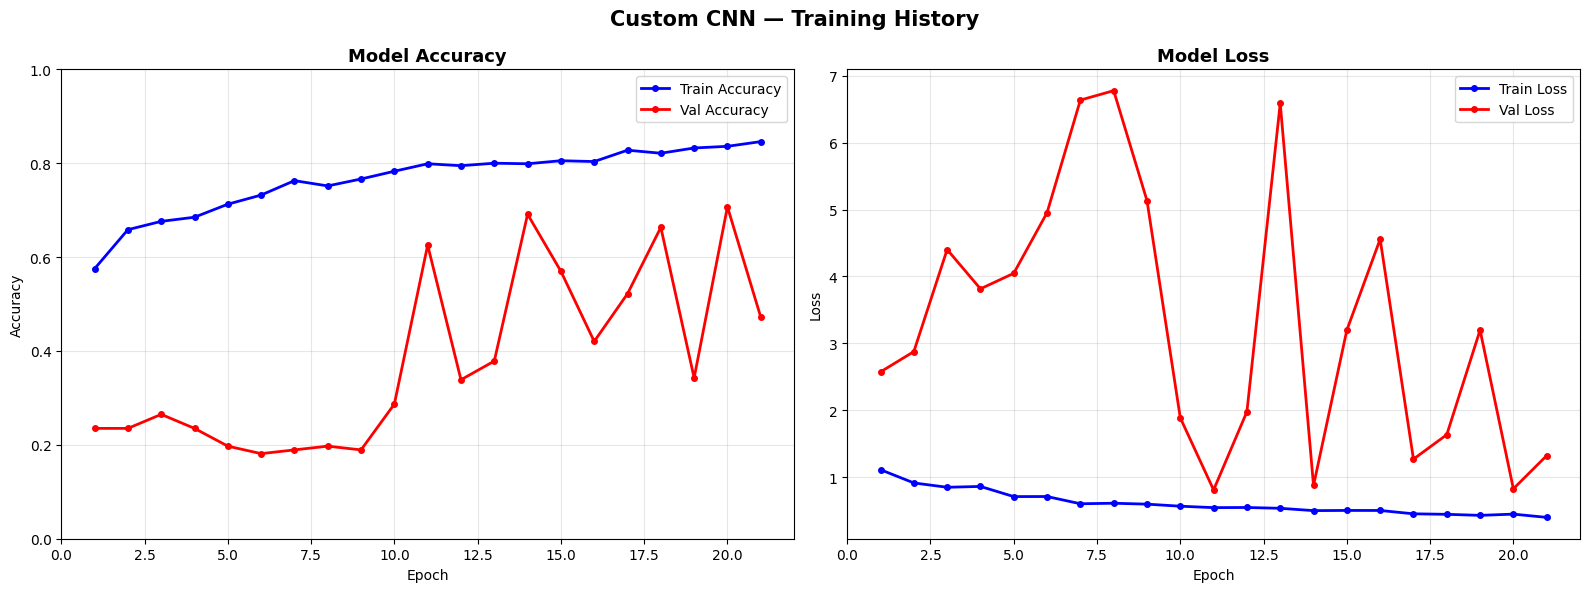

 Training history plot saved to Drive


In [14]:
#  Plot Training History

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Custom CNN — Training History', fontsize=15, fontweight='bold')

epochs_ran = range(1, len(history.history['loss']) + 1)

# Accuracy plot
axes[0].plot(epochs_ran, history.history['accuracy'],
             'b-o', linewidth=2, markersize=4, label='Train Accuracy')
axes[0].plot(epochs_ran, history.history['val_accuracy'],
             'r-o', linewidth=2, markersize=4, label='Val Accuracy')
axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# Loss plot
axes[1].plot(epochs_ran, history.history['loss'],
             'b-o', linewidth=2, markersize=4, label='Train Loss')
axes[1].plot(epochs_ran, history.history['val_loss'],
             'r-o', linewidth=2, markersize=4, label='Val Loss')
axes[1].set_title('Model Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/BrainTumor/models/custom_cnn_history.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Training history plot saved to Drive")

In [15]:
# Evaluate on Test Set

print(" Evaluating Custom CNN on Test Set...")
print("=" * 50)

# Get predictions
test_generator.reset()
predictions  = model.predict(test_generator, verbose=1)
pred_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

# Overall accuracy
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f"\n Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f" Test Loss     : {test_loss:.4f}")

# Classification report
print("\n Classification Report:")
print("=" * 50)
print(classification_report(true_classes, pred_classes,
                             target_names=CLASSES))

 Evaluating Custom CNN on Test Set...
8/8 ━━━━━━━━━━━━━━━━━━━━ 67s 9s/step

 Test Accuracy : 0.6504 (65.04%)
 Test Loss     : 0.7577

 Classification Report:
              precision    recall  f1-score   support

      glioma       1.00      0.62      0.77        80
  meningioma       0.44      0.29      0.35        63
    no_tumor       0.51      0.82      0.62        49
   pituitary       0.68      0.96      0.80        54

    accuracy                           0.65       246
   macro avg       0.66      0.67      0.64       246
weighted avg       0.69      0.65      0.64       246



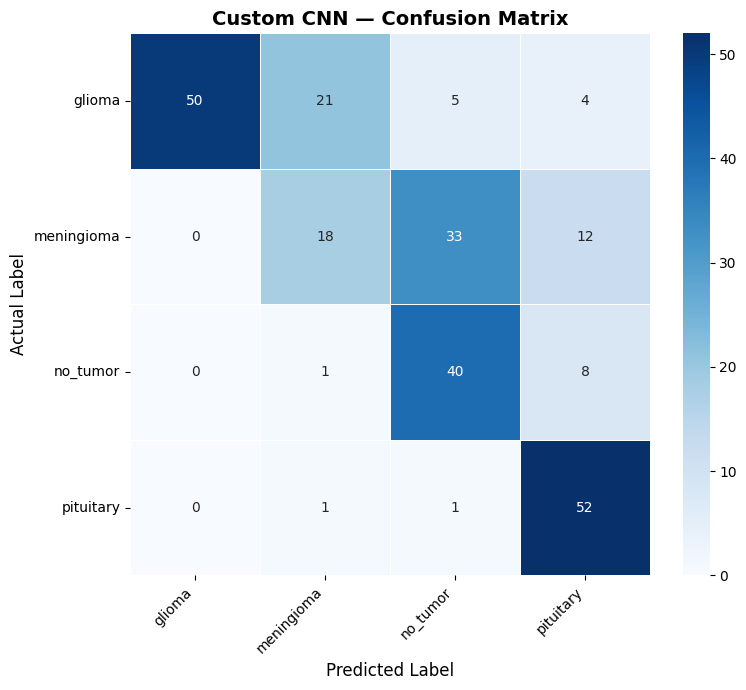

 Confusion matrix saved to Drive


In [16]:
# Confusion Matrix

cm = confusion_matrix(true_classes, pred_classes)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    cm,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels= CLASSES,
    yticklabels= CLASSES,
    linewidths = 0.5
)
ax.set_title('Custom CNN — Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/BrainTumor/models/custom_cnn_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion matrix saved to Drive")

In [19]:
# Save Results Summary

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(true_classes, pred_classes, average='weighted')
recall    = recall_score(true_classes, pred_classes, average='weighted')
f1        = f1_score(true_classes, pred_classes, average='weighted')

print("=" * 55)
print("        CUSTOM CNN — FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"  Test Accuracy  : {test_acc*100:.2f}%")
print(f"  Test Loss      : {test_loss:.4f}")
print(f"  Precision      : {precision:.4f}")
print(f"  Recall         : {recall:.4f}")
print(f"  F1 Score       : {f1:.4f}")
print(f"  Model saved at : {MODEL_SAVE_PATH}")
print("=" * 55)
print("\n  Next Step → Notebook 4: Transfer Learning")

# Save metrics to csv for comparison later
metrics_df = pd.DataFrame([{
    'Model'    : 'Custom CNN',
    'Accuracy' : round(test_acc * 100, 2),
    'Precision': round(precision, 4),
    'Recall'   : round(recall, 4),
    'F1_Score' : round(f1, 4),
    'Loss'     : round(test_loss, 4)
}])
metrics_df.to_csv(
    '/content/drive/MyDrive/BrainTumor/models/model_results.csv',
    index=False
)
print("\n Results saved to model_results.csv")

        CUSTOM CNN — FINAL RESULTS SUMMARY
  Test Accuracy  : 65.04%
  Test Loss      : 0.7577
  Precision      : 0.6887
  Recall         : 0.6504
  F1 Score       : 0.6389
  Model saved at : /content/drive/MyDrive/BrainTumor/models/custom_cnn.h5

  Next Step → Notebook 4: Transfer Learning

 Results saved to model_results.csv
